###NASA Earth Exchange Global Daily Downscaled Climate Projections
In this workflow, we are going to work with NASA Earth Exchange Global Daily Downscaled Climate Projections (NEX-GDDP-CMIP6). The data are located on Google Earth Engine, among other places.
https://developers.google.com/earth-engine/datasets/catalog/NASA_GDDP-CMIP6

For GEE, you need to navigate to https://earthengine.google.com/
1. Click on "Get Started" at the top left.
2. Click "Register a Noncommercial or Commercial Cloud Project"
3. Select "Unpaid usage":
  - Project Type = "Academia & Research".
  - Click "NEXT"
4. Choose "Create a new Google Cloud Project":
  - Organization: some name
  - Project-ID = some name
  - Project Name = make blank. Mine is 'ee-jeremypal'
  - Click "CONTINUE WITH REGISTRATION"
5. Continue with remaining prompts

In [1]:
# COLAB ONLY: Install required modules
#!pip install xarray geemap rasterio cartopy contextily

In [97]:
import xarray as xr
import math
import pandas as pd
import geemap
import ee
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import contextily as ctx
import datetime
import numpy as np
from scipy.stats import genextreme
from scipy.optimize import curve_fit


# Specify location coordinates, e.g., city center
#   South and east should be negative
lat_loc, lon_loc = 45.44, 12.32

# Specify Surface Variable
variable = 'pr'
variables = [
    'hurs',   # [%] Relative humidity. Not present in 'BCC-CSM2-MR', 'NESM3', 'KIOST-ESM' (only for 'ssp245' in 2058)
    'huss',   # [Mass fraction] Specific humidity. Not present in 'IPSL-CM6A-LR', 'MIROC6', 'NESM3'
    'pr',     # [kg/m2/s] Precipitation
    'rlds',   # [W/m2] Surface downwelling longwave radiation
    'rsds',   # [W/m2] Surface downwelling shortwave radiation
    'sfcWind',# [m/s] Near-surface wind speed
    'tas',    # [K] Air temperature. Not present in: 'NorESM2-LM' (only for 'ssp585' in 2096)
    'tasmin', # [K] Daily minimum air temperature. Not present in 'CESM2', 'CESM2-WACCM', 'IITM-ESM', 'TaiESM1' (only for 'ssp585' in 2093)
    'tasmax'  # [K] Daily maximum air temperature. Not present in 'CESM2', 'CESM2-WACCM', 'IITM-ESM'
]

# Specify historical and scenario years
# - Historical years must be between 1950 and 2014
# - Scenario years must be between 2015 and 2100
#year1_hist, year2_hist = 1985, 2014
#year1_scen, year2_scen = 2071, 2100
year1_hist, year2_hist = 1985, 2014
year1_scen, year2_scen = 2071, 2100

# Specify scenario
scenarios = ['historical', 'ssp245', 'ssp585']
scenario = 'ssp585'

# Specify climate model
models = ['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM',
          'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM5',
          'EC-Earth3', 'EC-Earth3-Veg-LR', 'FGOALS-g3', 'GFDL-CM4', 'GFDL-ESM4',
          'GISS-E2-1-G', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'IITM-ESM',
          'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'KACE-1-0-G', 'KIOST-ESM',
          'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0',
          'NESM3', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']
model = 'CMCC-ESM2'

# Define the return periods
return_periods = [2, 5, 10, 25, 50, 100, 200, 500]

# Annual Maxima Durations
# - Note that durations less than 24-hours are extrapolated because daily data
durations = [1, 6, 12, 24, 48, 72]

if variable not in variables:
    raise ValueError(f'VARIABLE SELECTION ERROR: {variable} must be one of: {variables}')
if model not in models:
    raise ValueError(f'MODEL SELECTION ERROR: {model} must be one of: {model}')
if scenario not in scenarios:
    raise ValueError(f'SCENARIO SELECTION ERROR: {scenario} must be one of: {scenarios}')

if not (1950 <= year1_hist <= 2014 and 1950 <= year2_hist <= 2014 and
        2015 <= year1_scen <= 2100 and 2015 <= year2_scen <= 2100 and
        year1_hist < year2_hist and year1_scen < year2_scen):
    raise ValueError('YEAR SELECTION ERROR'
        f'  Historical years must be between 1950 and 2014: {year1_hist} {year2_hist}'
        f'  Scenario years must be between 2015 and 2100: {year1_scen} {year2_scen}'
         '  The first year must be less than the second for both historical and scenario data.')

print('Modules loaded and parameters set')

Modules loaded and parameters set


# Authenticate and initialize GEE

In [4]:
#   If EE gives problems run the below command and follow browser steps
!earthengine authenticate --force

ee.Authenticate()
ee.Initialize()

E0000 00:00:1745584761.488736   70892 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745584761.501661   70892 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Authenticate: Limited support in Colab. Use ee.Authenticate() or --auth_mode=notebook instead.
To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20https%3A//www.googleapis.com/auth/drive%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=wuBXw2FNpuMTyx10sO7yFQUvwwqbm85KG9kHXcO3YVE&tc=8pJSSScwHh8BfLn7eLvlSt2BEze_d4JEASD

#Load NASA-GDDP-CMIP6 Variable

In [5]:
climate_dataset = ee.ImageCollection('NASA/GDDP-CMIP6').select(variable)
print(f'Variable "{variable}" Loaded')

# Determine dataset scale in meters
sample_image = ee.Image(climate_dataset.first())  # Any image from the dataset
scale = sample_image.projection().nominalScale().getInfo()
print(f'Dataset scale is {scale} m')

Variable "pr" Loaded
Dataset scale is 27829.87269831839 m


###Filter values at point

In [7]:
# Target point and parameters
target_point = ee.Geometry.Point(lon_loc, lat_loc)

# Function to extract point value
def extract_value(img):
    value = img.sample(target_point, scale=scale, dropNulls=False).first().get(variable)
    return img.set({
        'time': img.date().format('YYYY-MM-dd'),
        'value': value  # Store pixel value as a property
    })

# Filter historical data
collection_hist = (
    climate_dataset
    .filter(ee.Filter.eq('model', model))
    .filter(ee.Filter.eq('scenario', 'historical'))
    .filterDate(f'{year1_hist}-01-01', f'{year2_hist}-12-31')
    .filterBounds(target_point)
    .map(extract_value)  # Use the function to extract values
)

# Filter scenario data
collection_scen = (
    climate_dataset
    .filter(ee.Filter.eq('model', model))
    .filter(ee.Filter.eq('scenario', scenario))
    .filterDate(f'{year1_scen}-01-01', f'{year2_scen}-12-31')
    .filterBounds(target_point)
    .map(extract_value)  # Use the function to extract values
)

print('Filters set')

Filters set


### Extract values based on filters

In [8]:
# Function to extract values
def get_values(collection):
    # Extract the 'time' and 'value' properties
    result = collection.reduceColumns(
        reducer=ee.Reducer.toList(2),
        selectors=['time', 'value']  # Use 'value', not the variable name!
    ).get('list')
    data = result.getInfo()
    return list(zip(*data)) if data else ([], [])

print('This step can take some time. Be patient')
# Get data
print('  Extracting historical data')
times_hist, vals_hist = get_values(collection_hist)
print('  Extracting scenario data')
times_scen, vals_scen = get_values(collection_scen)
print('\nDone')

This step can take some time. Be patient
  Extracting historical data
  Extracting scenario data

Done


###Check that data was loaded

In [9]:
print(f'Historical: {len(times_hist)} times, {len(vals_hist)} values')
print(vals_hist)
print(f'Scenario: {len(times_scen)} times, {len(vals_scen)} values')
print(times_hist)

Historical: 10956 times, 10956 values
(3.320393443573266e-05, 3.587355968193151e-05, 0, 0, 9.19513240660308e-06, 5.323869481799193e-05, 1.870602136477828e-05, 0, 1.1348597581672948e-05, 3.7999121559550986e-05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8.24360267870361e-06, 5.030786996940151e-05, 9.274896729039028e-05, 2.833150210790336e-05, 0, 1.8328662918065675e-05, 4.1517350837239064e-06, 0, 7.370581442955881e-05, 0, 4.798623194801621e-05, 1.643903124204371e-05, 0, 7.332370842050295e-06, 1.9553812308004126e-05, 0, 0, 0, 0, 2.3777363367116777e-06, 0, 0, 0.00011165831529069692, 0.00014925605501048267, 2.323314402019605e-05, 0, 0, 0, 0.00010843837662832811, 0, 2.5672117772046477e-05, 2.8942748031113297e-05, 0, 0, 0.00012387412425596267, 5.881467222934589e-05, 0.00016330144717358053, 0.00016708443581592292, 0, 0, 0, 0, 0, 0, 0, 3.2995783385558752e-06, 2.476383997418452e-05, 3.3253993478865596e-06, 5.287508429319132e-06, 0, 1.1163139788550325e-05, 0.00019684004655573517, 3.610979

###Convert Earth Engine data to a dataframe
Dataframes are a two-dimensional data organized with rows and columns (similar to spreadsheets). Pandas is Python tool/module used to process dataframes.

In [30]:
# Convert EE time strings to datetime objects
df_day_hist = pd.DataFrame({
    'date': pd.to_datetime(times_hist),  # Direct conversion from string
    'Historical': vals_hist
})

df_day_scen = pd.DataFrame({
    'date': pd.to_datetime(times_scen),
    scenario: vals_scen
})

# Handle null values (if any)
df_day_hist = df_day_hist.dropna()
df_day_scen = df_day_scen.dropna()

print('GEE Data Converted to DataFrame')

GEE Data Converted to DataFrame


###Perform any necessary unit converstions and set variable units

In [31]:
# Unit conversions
if variable == 'tas':
    # Convert Kelvin to Celsius
    df_day_hist['Historical'] = df_day_hist['Historical'] - 273.15
    df_day_scen[scenario] = df_day_scen[scenario] - 273.15
    var_units = '°C'
elif variable == 'pr':
    # Convert kg/m²/s to mm/day (1 kg/m² = 1 mm, 86400 seconds/day)
    df_day_hist['Historical'] = df_day_hist['Historical'] * 86400
    df_day_scen[scenario] = df_day_scen[scenario] * 86400
    var_units = 'mm/hr'

###Check the data

In [32]:
print('\nHistorical Data:')
print(df_day_hist)
print('\nScenario Data:')
print(df_day_scen)


Historical Data:
            date  Historical
0     1985-01-01    2.868820
1     1985-01-02    3.099476
2     1985-01-03    0.000000
3     1985-01-04    0.000000
4     1985-01-05    0.794459
...          ...         ...
10951 2014-12-26    0.000000
10952 2014-12-27    5.619953
10953 2014-12-28    0.000000
10954 2014-12-29    6.574449
10955 2014-12-30    0.000000

[10956 rows x 2 columns]

Scenario Data:
            date     ssp585
0     2071-01-01  40.734073
1     2071-01-02   2.752079
2     2071-01-03   0.501017
3     2071-01-04   0.000000
4     2071-01-05   0.000000
...          ...        ...
10951 2100-12-26   0.000000
10952 2100-12-27   0.000000
10953 2100-12-28   0.000000
10954 2100-12-29   0.000000
10955 2100-12-30   0.000000

[10956 rows x 2 columns]


###Plot Data

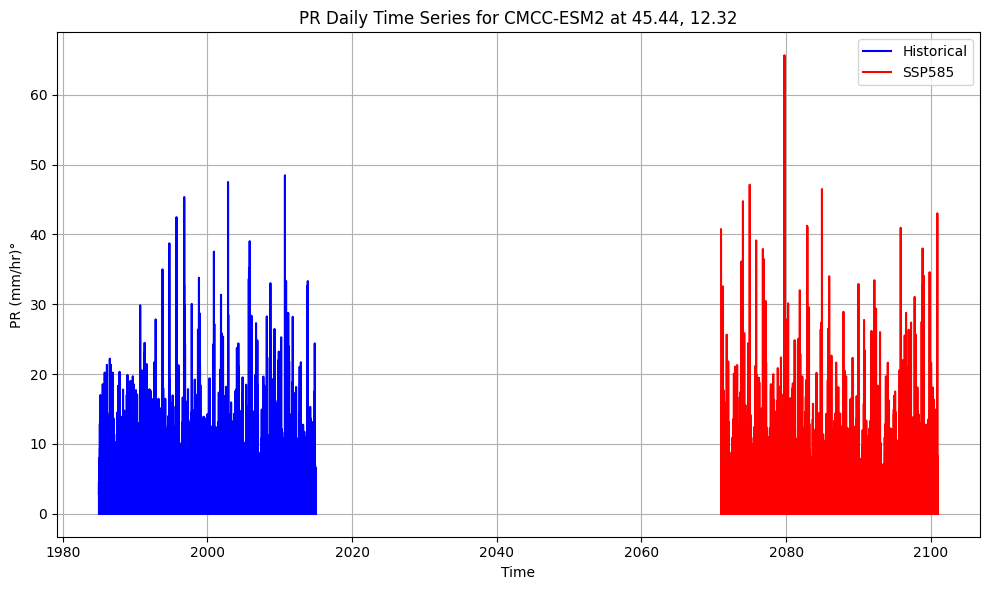

In [34]:
# Plot each DataFrame independently
plt.figure(figsize=(10, 6))

# Plot df_mon_hist
plt.plot(df_day_hist['date'], df_day_hist['Historical'], label='Historical',
         color='blue')

# Plot df_mon_scen
plt.plot(df_day_scen['date'], df_day_scen[scenario], label=scenario.upper(),
         color='red')

# Add labels, title, and legend
plt.xlabel('Time')
plt.ylabel(f'{variable.upper()} ({var_units})')
plt.title(f'{variable.upper()} Daily Time Series for {model} at {lat_loc}, {lon_loc}')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

### Determine Annual Maxima
Since the data are daily, the annual maxima are computed for durations of 24-hr or greater.

In [17]:
# Extract the year from time column and add as column
df_day_hist['year'] = df_day_hist['date'].dt.year
df_day_scen['year'] = df_day_scen['date'].dt.year

# Compute annual maxima for durations 24-hours and greater
for duration in [d for d in durations if d >= 24]:
    if duration == 24:
        df_annmax_hist = (
            df_day_hist
            .groupby('year')
            .agg({'Historical': 'max'})
            .reset_index()
            .rename(columns={'Historical': f'{duration}-hr'})
        )
        df_annmax_scen = (
            df_day_scen
            .groupby('year')
            .agg({scenario: 'max'})
            .reset_index()
            .rename(columns={scenario: f'{duration}-hr'})
        )
    else:
        window = duration // 24
        df_annmax_hist[f'{duration}-hr'] = df_day_hist.groupby('year')['Historical'].apply(
            lambda x: x.rolling(window=window, min_periods=window).sum().max()
        ).values

        # Compute the annual rolling maximum for scenario data.
        df_annmax_scen[f'{duration}-hr'] = df_day_scen.groupby('year')[scenario].apply(
            lambda x: x.rolling(window=window, min_periods=window).sum().max()
        ).values

# Remove the 'year' column
df_day_hist = df_day_hist.drop(columns=['year'])
df_day_scen = df_day_scen.drop(columns=['year'])

print(f'Done compute annual maxima for durations ≥ 24-hours')

Done compute annual maxima for durations ≥ 24-hours


###Check data

In [18]:
print(df_annmax_hist)
print(df_annmax_scen)

    year      24-hr      48-hr      72-hr
0   1985  20.224683  34.356580  53.410524
1   1986  22.215133  32.866633  37.674333
2   1987  20.331206  29.940188  30.890904
3   1988  19.871260  25.216327  37.055784
4   1989  19.693748  31.341992  37.056366
5   1990  29.856861  36.524871  52.395363
6   1991  24.483238  40.687273  44.424781
7   1992  27.833464  37.757412  48.663143
8   1993  35.002330  64.190164  83.053412
9   1994  38.735208  51.270438  54.202215
10  1995  42.476344  75.468038  81.428858
11  1996  45.358128  68.692544  83.205678
12  1997  30.056697  37.320086  44.158098
13  1998  33.809754  55.986922  64.014933
14  1999  18.436973  25.552663  35.694900
15  2000  37.543779  52.668870  63.266679
16  2001  31.359778  56.853519  66.068678
17  2002  47.513638  62.168322  73.211200
18  2003  17.836475  29.580084  34.574014
19  2004  24.399480  34.078303  49.956863
20  2005  39.039048  64.115034  78.395379
21  2006  28.375573  40.833934  41.193442
22  2007  19.644959  29.274694  29

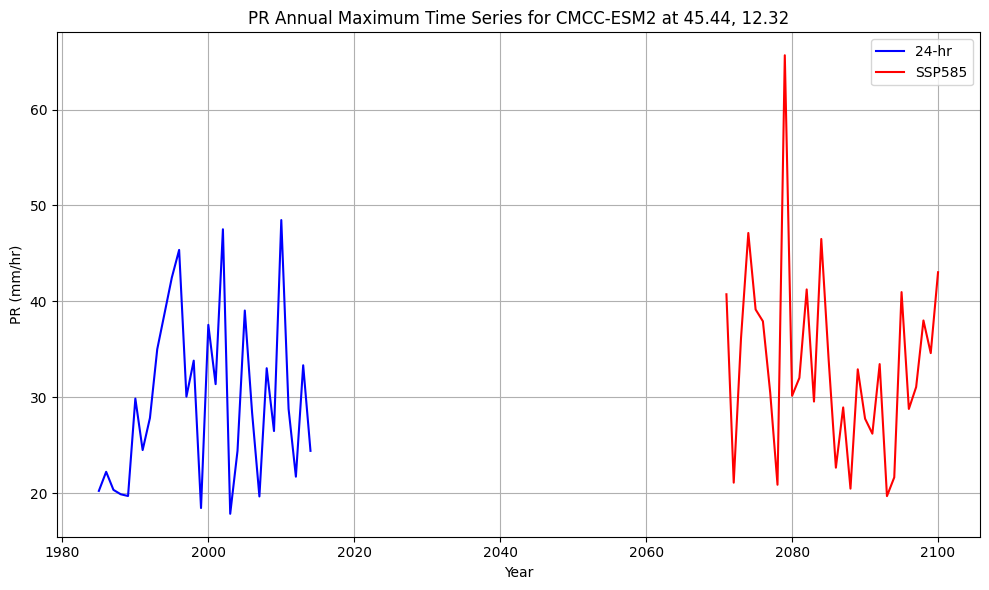

In [35]:
plt.figure(figsize=(10, 6))

# Plot df_mon_hist
plt.plot(df_annmax_hist['year'], df_annmax_hist['24-hr'],
         label='24-hr', color='blue')

# Plot df_mon_scen
plt.plot(df_annmax_scen['year'], df_annmax_scen['24-hr'],
         label=scenario.upper(), color='red')

# Add labels, title, and legend
plt.xlabel('Year')
plt.ylabel(f'{variable.upper()} ({var_units})')
plt.title(f'{variable.upper()} Annual Maximum Time Series for {model} at {lat_loc}, {lon_loc}')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

# Extreme Value Analysis
Here we will compute the rainfall volumes for each return period and event duration using Generalized Extreme Value (GEV) distribution.

###Load GEV function

In [36]:
def gev_magnitudes(data, return_periods):
    """
    Fits a Generalized Extreme Value (GEV) distribution to the input data
    and computes event magnitudes for specified return periods.

    Parameters:
        data (array-like): Annual maxima data to fit the distribution.
        return_periods (list): List of return periods for which to compute magnitudes.

    Returns:
        list: Rainfall magnitudes corresponding to each return period.
    """
    # Fit the GEV distribution
    shape, loc, scale = genextreme.fit(data)

    # Calculate event magnitudes for each return period
    magnitudes = []
    for rp in return_periods:
        # Exceedance probability: 1 - 1 / return period
        exceedance_prob = 1 - 1 / rp
        # Calculate rainfall magnitude using the percent-point function (PPF)
        mag = genextreme.ppf(exceedance_prob, shape, loc=loc, scale=scale)
        magnitudes.append(mag)

    return magnitudes

print('GEV function loaded')

GEV function loaded


###Compute magnitudes associated with each return period
This step is done only for annual maximum data with durations of 24-hours or greater. A later step will extrapolate to lower durations.

In [37]:
# Initialize empty dictionaries to store results for each duration
rps_hist = {}
rps_scen = {}

# Perform extreme value analysis for each duration
for duration in [d for d in durations if d >= 24]:

    # Extract the data for each duration and convert to intensity
    annmax_dur = df_annmax_hist[f'{duration}-hr'].dropna() / duration
    # Perform GEV analysis
    gev_mags = gev_magnitudes(annmax_dur, return_periods)
    # Save dictionary
    rps_hist[f'{duration}-hr'] = gev_mags

    # Repeat above for the scenario
    annmax_dur = df_annmax_scen[f'{duration}-hr'].dropna() / duration
    gev_mags = gev_magnitudes(annmax_dur, return_periods)
    rps_scen[f'{duration}-hr'] = gev_mags

# Create a DataFrame
df_rps_hist = pd.DataFrame(
    rps_hist,
    index=return_periods
)
df_rps_scen = pd.DataFrame(
    rps_scen,
    index=return_periods
)

# Add a column for Return Period (optional, for clarity)
df_rps_hist.index.name = 'Return Period'
df_rps_scen.index.name = 'Return Period'

print('Done extreme value analysis')

Done extreme value analysis


###Check the data

In [38]:
print(df_rps_hist)
print(df_rps_scen)

                  24-hr     48-hr     72-hr
Return Period                              
2              1.160228  0.824545  0.694695
5              1.500105  1.091464  0.894454
10             1.737334  1.303648  1.024600
25             2.051730  1.620295  1.186670
50             2.296024  1.896147  1.305217
100            2.548248  2.210134  1.421489
200            2.809581  2.568603  1.535964
500            3.170357  3.122576  1.684926
                  24-hr     48-hr     72-hr
Return Period                              
2              1.329601  0.931798  0.716271
5              1.691596  1.231006  0.935056
10             1.927388  1.449940  1.111769
25             2.220961  1.752805  1.379372
50             2.435656  1.998099  1.615793
100            2.646195  2.260453  1.888146
200            2.853448  2.541992  2.202817
500            3.123086  2.946830  2.695926


###Plot the results

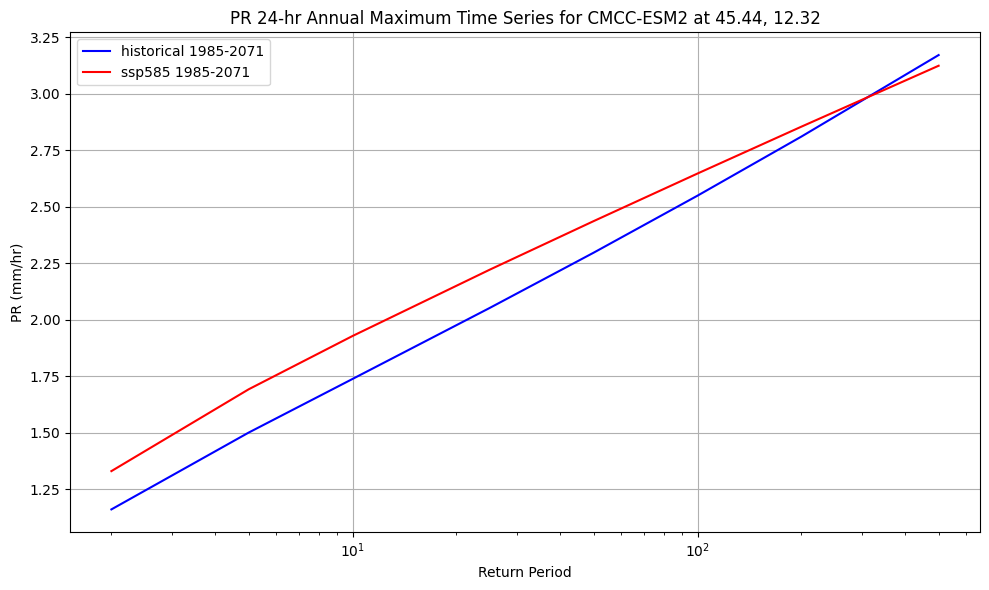

In [39]:
plt.figure(figsize=(10, 6))

# Plot df_rps_hist
plt.plot(df_rps_hist['24-hr'], label=f'historical {year1_hist}-{year1_scen}', color='blue')

# Plot df_rps_scen
plt.plot(df_rps_scen['24-hr'], label=f'{scenario} {year1_hist}-{year1_scen}', color='red')

plt.xscale('log')

# Add labels, title, and legend
plt.xlabel('Return Period')
plt.ylabel(f'{variable.upper()} ({var_units})')
plt.title(f'{variable.upper()} 24-hr Annual Maximum Time Series for {model} at {lat_loc}, {lon_loc}')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

###Use a parametric IDF model to extrapolate return period intensities to lower durations.

I = (k * T^m) / (D + c)^n

Where:

- I = Rainfall intensity (mm/hour)
- T = Return period (years)
- D = Duration (hours)
- k, m, c, n = Fitted parameters

In [46]:
data = []
for rp in df_rps_hist.index:
    for duration in [d for d in durations if d >= 24]:
        I = df_rps_hist.loc[rp, f'{duration}-hr']
        data.append((rp, duration, I))

print(data)

# Convert to arrays
T = np.array([x[0] for x in data])
D = np.array([x[1] for x in data])
I = np.array([x[2] for x in data])

# IDF shape model
def idf_model(xdata, k, m, c, n):
    T, D = xdata
    return (k * T**m) / (D + c)**n

# Initial guess and bounds
initial_guess = [1, 0.5, 1, 0.5]  # [k, m, c, n]
bounds = ([0.1, 0.1, 0, 0.1], [10, 2, 20, 2])

# Fit globally
params_opt, _ = curve_fit(
    idf_model,
    xdata=(T, D),
    ydata=I,
    p0=initial_guess,
    bounds=bounds,
    maxfev=5000
)

# Extract parameters
k, m, c, n = params_opt

# Extrapolate to lower durations
results = df_rps_hist.copy()
for duration in [d for d in durations if d < 24]:
    new_col = f'{duration}-hr'
    # Compute intensity for all return periods
    results[new_col] = [(k * rp**m) / (duration + c)**n for rp in results.index]

# Reorder columns to show 1h/6h first
column_order = ['1-hr', '6-hr'] + [f'{d}-hr' for d in durations]
results = results[column_order]

# Ensure intensity increases with return period
results = results.apply(lambda col: col.sort_values(ascending=True).values, axis=0)
results = results.round(3)

print("Extrapolate IDF Table")
print(results)

[(2, 24, np.float64(1.160228186177225)), (2, 48, np.float64(0.8245449739764888)), (2, 72, np.float64(0.6946949021312229)), (5, 24, np.float64(1.5001053235651323)), (5, 48, np.float64(1.0914641659922513)), (5, 72, np.float64(0.894454442887386)), (10, 24, np.float64(1.7373344373164763)), (10, 48, np.float64(1.3036476290478838)), (10, 72, np.float64(1.024599666868037)), (25, 24, np.float64(2.051729953983104)), (25, 48, np.float64(1.6202945701242568)), (25, 72, np.float64(1.1866698315173199)), (50, 24, np.float64(2.2960241648110298)), (50, 48, np.float64(1.8961474560911395)), (50, 72, np.float64(1.3052173880666778)), (100, 24, np.float64(2.548247754718707)), (100, 48, np.float64(2.210134334312098)), (100, 72, np.float64(1.4214887705806918)), (200, 24, np.float64(2.809581285298239)), (200, 48, np.float64(2.5686026162715305)), (200, 72, np.float64(1.535964364857917)), (500, 24, np.float64(3.17035703974393)), (500, 48, np.float64(3.122576435905641)), (500, 72, np.float64(1.6849260304867864))]

In [48]:
def extrapolate_idf(df_input, target_durations=[1, 6], min_duration=24, round_decimals=3):
    """
    Extrapolates IDF curves to shorter durations using a parametric model.

    Parameters:
    - df_input: DataFrame with columns like '24-hr', '48-hr', etc., indexed by return period
    - target_durations: List of durations (hours) to extrapolate to (e.g., [1, 6])
    - min_duration: Minimum duration (hours) to use for model fitting
    - round_decimals: Number of decimal places for output

    Returns:
    - DataFrame with original + extrapolated durations, sorted by duration
    """

    # ===== 1. Prepare Data =====
    durations = [int(col.split('-')[0]) for col in df_input.columns]
    data = []
    for rp in df_input.index:
        for d in [d for d in durations if d >= min_duration]:
            I = df_input.loc[rp, f'{d}-hr']
            data.append((rp, d, I))

    T = np.array([x[0] for x in data])
    D = np.array([x[1] for x in data])
    I = np.array([x[2] for x in data])

    # ===== 2. Define and Fit Model =====
    def idf_model(xdata, k, m, c, n):
        T, D = xdata
        return (k * T**m) / (D + c)**n

    params_opt, _ = curve_fit(
        idf_model,
        (T, D), I,
        p0=[1, 0.5, 1, 0.5],
        bounds=([0.1, 0.1, 0, 0.1], [10, 2, 20, 2]),
        maxfev=5000
    )
    k, m, c, n = params_opt

    # ===== 3. Extrapolate =====
    df_out = df_input.copy()
    for d in target_durations:
        df_out[f'{d}-hr'] = [(k * rp**m) / (d + c)**n for rp in df_out.index]

    # ===== 4. Post-process =====
    # Sort columns by duration
    all_durations = target_durations + durations
    column_order = [f'{d}-hr' for d in sorted(all_durations, reverse=False)]
    df_out = df_out[column_order]

    # Ensure monotonicity
    df_out = df_out.apply(lambda col: col.sort_values(ascending=True).values, axis=0)

    return df_out.round(round_decimals)

print('IDF Extrapolation function loaded')

IDF Extrapolation function loaded


### Run parametric IDF model extrapolation

In [53]:
extrap_durations = [d for d in durations if d < 24]
df_idf_hist = extrapolate_idf(
    df_rps_hist,
    target_durations=extrap_durations,
    min_duration=24,           # Only use >=24h for fitting
    round_decimals=3
)
df_idf_scen = extrapolate_idf(
    df_rps_scen,
    target_durations=extrap_durations,
    min_duration=24,
    round_decimals=3
)

###Check the results

In [54]:
print("Extended IDF Table:")
print(df_idf_hist)
print(df_idf_scen)

Extended IDF Table:
                1-hr   6-hr  12-hr  24-hr  48-hr  72-hr
Return Period                                          
2              2.105  1.801  1.557  1.160  0.825  0.695
5              2.487  2.128  1.840  1.500  1.091  0.894
10             2.822  2.414  2.088  1.737  1.304  1.025
25             3.334  2.853  2.467  2.052  1.620  1.187
50             3.782  3.236  2.798  2.296  1.896  1.305
100            4.291  3.671  3.175  2.548  2.210  1.421
200            4.868  4.165  3.601  2.810  2.569  1.536
500            5.752  4.921  4.255  3.170  3.123  1.685
                1-hr   6-hr  12-hr  24-hr  48-hr  72-hr
Return Period                                          
2              1.818  1.657  1.514  1.330  0.932  0.716
5              2.134  1.946  1.778  1.692  1.231  0.935
10             2.410  2.197  2.008  1.927  1.450  1.112
25             2.830  2.579  2.357  2.221  1.753  1.379
50             3.195  2.913  2.662  2.436  1.998  1.616
100            3.608  3.289 

<ipython-input-96-12473d40057f>:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('rainbow', n_rps)


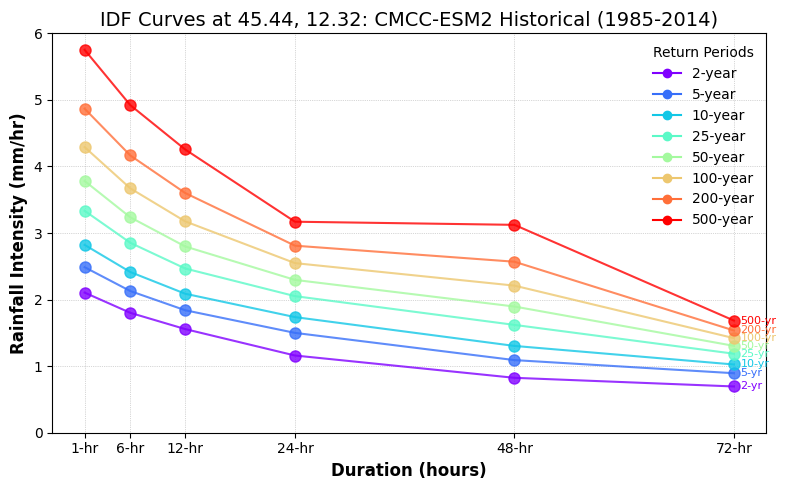

<ipython-input-96-12473d40057f>:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('rainbow', n_rps)


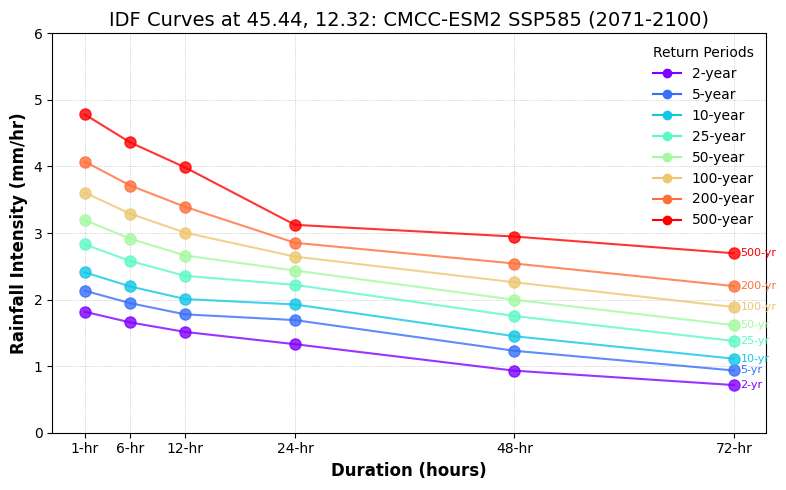

In [96]:
def plot_idf_curves(df_idf, durations, year1, year2, scenario, plot_title,
                    vmin, vmax):
    xtick_labels = [f'{d}-hr' for d in durations]

    rps = list(df_idf.index)
    n_rps = len(rps)

    cmap = cm.get_cmap('rainbow', n_rps)

    plt.figure(figsize=(8, 5))

    legend_handles = []

    for idx, rp in enumerate(rps):
        color = cmap(idx)
        y = df_idf.loc[rp].values.astype(float)
        plt.plot(durations, y, marker='o', markersize=8, linestyle='-', color=color, alpha=0.8)
        plt.text(durations[-1]*1.01, y[-1], f'{rp}-yr', fontsize=8, color=color, ha='left', va='center')
        legend_handles.append(Line2D([], [], color=color, marker='o', linestyle='-', label=f'{rp}-year'))

    ax = plt.gca()
    ax.set_xticks(durations)
    ax.set_xticklabels(xtick_labels)
    ax.set_ylim(vmin, vmax)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    plt.grid(True, which='both', linestyle=':', linewidth=0.5)
    plt.xlabel('Duration (hours)', fontsize=12, fontweight='bold')
    plt.ylabel('Rainfall Intensity (mm/hr)', fontsize=12, fontweight='bold')
    plt.title(plot_title, fontsize=14)
    plt.legend(handles=legend_handles, loc='upper right', title='Return Periods', frameon=False)

    plt.tight_layout()
    plt.show()

plot_title = f'IDF Curves at {lat_loc}, {lon_loc}: {model} Historical ({year1_hist}-{year2_hist})'
plot_idf_curves(df_idf_hist, durations, year1_hist, year2_hist, 'historical',
                plot_title, 0, 6)
plot_title = f'IDF Curves at {lat_loc}, {lon_loc}: {model} {scenario.upper()} ({year1_scen}-{year2_scen})'
plot_idf_curves(df_idf_scen, durations, year1_scen, year2_scen, scenario,
                plot_title, 0, 6)